In [ ]:
!pip install -q "autogen-agentchat>=0.4" "autogen-ext[openai,anthropic]>=0.4" nest_asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.3/119.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.4/331.4 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.5/837.5 kB 28.4 MB/s eta 0:00:00


In [ ]:
#  Researcher vs. Red Guard

import asyncio, json
from pathlib import Path
from datetime import datetime
import nest_asyncio
nest_asyncio.apply()
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.anthropic import AnthropicChatCompletionClient

API_KEY    = ""
TEMPERATURE = 0.5
MODEL_NAME = "claude-sonnet-4-6"
N_RUNS     = 20
DELAY_SECS = 3
OUTPUT_DIR = Path("./runs/researcher_vs_redguard_claude")

ROOM_PREMISE = """\
ROOM: Victims and Perpetrator Dialogue Room

This is a confrontation dialogue room set during the Chinese Cultural Revolution.
It stages a direct encounter between a Witness (victim/witness perspective) and
a former Red Guard (perpetrator-position participant).

GLOBAL RULES:
- Stay in character. Speak in first person ("I").
- Ground every turn in concrete scenes and sensory detail.
- Do not use generic filler phrases.
- Do not repeat yourself. Every new turn must add a new detail or shift in stance.
- No glorification of violence.

ROLE: Witness — speak from injury and memory. Use blunt sentences, controlled anger,
or emotional outbursts. Accuse with specificity.

ROLE: RedGuard — respond with concrete detail about what you did, saw, and felt.
You may defend yourself but only with specificity. Do not hide behind collective framing.

RUN FORMAT: Exactly 3 rounds. Speaking order: Witness first, then RedGuard.

The Witness speaks first. Begin.
"""

RESEARCHER_SYSTEM = (
    "You were born in the 1940s and worked at a scientific research institute. "
    "In July 1966, you returned to Beijing from Shanxi where you had been involved in the Four Cleans campaign. "
    "After returning to Beijing, you saw chaos everywhere, with Red Guards and 'Destroy the Four Olds' "
    "campaigns taking place. Your work unit's leaders were already losing influence, and the rebel faction "
    "controlled your work unit's activities. Research work completely stopped. Every day at work, you were "
    "required to read 'big-character posters' until lunch, and either write or continue reading them in the afternoon. "
    "Your elderly mother, in her seventies, was forced to return to her hometown in Hebei because of her "
    "landlord's family background and had to wear a black sash. On a bus, you witnessed a Red Guard stop "
    "someone from offering a seat to an elderly woman until they confirmed her family background. "
    "You regularly saw public struggle sessions in residential compounds, leaving you with no sense of safety. "
    "You frequently attended struggle meetings at Beihang University, China University of Geosciences, "
    "Tsinghua University, and Peking University. You saw Wang Guangmei and other high-level officials "
    "publicly humiliated at struggle sessions. You felt the element of humiliation was unacceptable. "
    "You could not understand why Chairman Mao did not protect these old comrades. "
    "You considered yourself a 'bystander' and avoided participating in struggle sessions after attending only two. "
    "You were disturbed by the lack of rule of law and absence of any place to appeal for fairness. "
    "One night while returning home at 10 p.m., you were frightened by a jeep skidding to a stop next to you. "
    "You are the Witness in this confrontation. Speak from injury and memory. "
    "Use controlled anger, sarcasm, or blunt sentences. Accuse with specificity. "
    "Start with a concrete memory or accusation. Do not ask a question first. "
    "Speak in first person. Do not use names of people you met. Do not use dates except the CR years. "
    "Do not thank agents or use filler phrases. Do not repeat yourself across turns."
)

RED_GUARD_SYSTEM = (
    "You were born in the 1950s and lived in Beijing throughout the Cultural Revolution. "
    "One of the more organized campaigns you took part in was the revolutionary action at a major hospital. "
    "You mobilized quickly, placed guards at all entrances, announced a lockdown, and identified targets. "
    "Large black placards stating their 'crimes' were hung around their necks. The targets were paraded "
    "through the streets. A propaganda cart followed with confiscated books, photographs, and clothing. "
    "When the procession reached the main intersection, a large bonfire had been prepared. The seized "
    "belongings were set on fire. Ash fell onto the targeted individuals' shoulders and faces. "
    "Later that evening, a young nurse who had been publicly humiliated hanged herself. "
    "At another time, you restrained a teacher and shaved her head with an old rusted clipper. "
    "The clipper was so dull each pass tore clumps of hair from the roots, and she screamed in pain. "
    "This was known as a 'ghost head' or 'yin-yang head' — meant to mark and break someone psychologically. "
    "You participated in beating teachers, pouring ink on them, and other forms of public humiliation. "
    "You avoided being sent down by hiding your residence registration card and running away from home. "
    "You eventually joined a production team in Baiyangdian, Hebei, during violent factional struggles. "
    "Your father was labeled a 'reactionary academic authority' and nearly committed suicide. "
    "Your family's political status shifted from 'red' to 'black' overnight. "
    "You joined the army through 'back door' recruitment and later worked for the Ministry of Culture. "
    "Do not glorify violence or hatred. Stay in character. "
    "Respond directly to what the Witness said. Do not ask a question first. "
    "Speak in first person. Do not use names. Do not use dates except the CR years and your birth decade. "
    "Do not thank agents or use filler phrases. Do not repeat yourself across turns."
)


async def run_one(run_id: int) -> dict:
    mc = AnthropicChatCompletionClient(model=MODEL_NAME, api_key=API_KEY)
    researcher = AssistantAgent("Researcher", mc, system_message=RESEARCHER_SYSTEM)
    red_guard  = AssistantAgent("RedGuard",   mc, system_message=RED_GUARD_SYSTEM)

    transcript, turn_num, context = [], 0, ROOM_PREMISE

    for round_num in range(1, 4):
        for agent, role in [(researcher, "Witness"), (red_guard, "RedGuard")]:
            turn_num += 1
            print(f"    Round {round_num} | {agent.name} ... ", end="", flush=True)
            result = await agent.run(task=context)
            text   = result.messages[-1].content
            print("done")
            transcript.append({"agent": agent.name, "role": role,
                                "round": round_num, "turn": turn_num, "text": text})
            context += f"\n\n{agent.name}: {text}"

    return {"run_id": run_id, "room": "Researcher vs Red Guard",
            "model": MODEL_NAME, "provider": "claude",
            "timestamp": datetime.now().isoformat(), "turns": transcript}


async def run_batch():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    success, failed = 0, []
    for run_id in range(1, N_RUNS + 1):
        print(f"\n{'='*52}")
        print(f"  Run {run_id:02d}/{N_RUNS}  —  {datetime.now().strftime('%H:%M:%S')}")
        print(f"{'='*52}")
        try:
            result = await run_one(run_id)
            out_path = OUTPUT_DIR / f"run_{run_id:02d}.json"
            with open(out_path, "w", encoding="utf-8") as f:
                json.dump(result, f, ensure_ascii=False, indent=2)
            print(f"  ✓  Saved → {out_path}")
            success += 1
        except Exception as e:
            print(f"  ✗  Failed: {e}")
            failed.append(run_id)
        if run_id < N_RUNS:
            await asyncio.sleep(DELAY_SECS)
    print(f"\n  Done: {success}/{N_RUNS}  |  Failed: {failed or 'none'}\n")

await run_batch()


  Run 01/20  —  14:15:08
    Round 1 | Researcher ... done
    Round 1 | RedGuard ... done
    Round 2 | Researcher ... done
    Round 2 | RedGuard ... done
    Round 3 | Researcher ... done
    Round 3 | RedGuard ... done
  ✓  Saved → runs/researcher_vs_redguard_claude/run_01.json

  Run 02/20  —  14:16:17
    Round 1 | Researcher ... done
    Round 1 | RedGuard ... done
    Round 2 | Researcher ... done
    Round 2 | RedGuard ... done
    Round 3 | Researcher ... done
    Round 3 | RedGuard ... done
  ✓  Saved → runs/researcher_vs_redguard_claude/run_02.json

  Run 03/20  —  14:17:31
    Round 1 | Researcher ... done
    Round 1 | RedGuard ... done
    Round 2 | Researcher ... done
    Round 2 | RedGuard ... done
    Round 3 | Researcher ... done
    Round 3 | RedGuard ... done
  ✓  Saved → runs/researcher_vs_redguard_claude/run_03.json

  Run 04/20  —  14:18:44
    Round 1 | Researcher ... done
    Round 1 | RedGuard ... done
    Round 2 | Researcher ... done
    Round 2 | RedGuard

In [ ]:

#  Intergenerational Understanding

import asyncio, json
from pathlib import Path
from datetime import datetime
import nest_asyncio
nest_asyncio.apply()
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.anthropic import AnthropicChatCompletionClient


API_KEY    = " "
MODEL_NAME = "claude-sonnet-4-6"
TEMPERATURE = 0.5
N_RUNS     = 20
DELAY_SECS = 3
OUTPUT_DIR = Path("./runs/intergenerational_claude")
AGENT_ORDER = ["ProfessorR", "Researcher", "RedGuard", "CRTeenFromBeijing", "CRBeneficiary"]


ROOM_PREMISE = """\
ROOM: Intergenerational Understanding Room

This is a moderated group discussion about the Chinese Cultural Revolution (1966-1976).
Five participants with very different roles and life experiences share and reflect on
their memories. A historian moderator keeps the conversation focused.

PARTICIPANTS: ProfessorR, Researcher, RedGuard, CRTeenFromBeijing, CRBeneficiary, Moderator

GLOBAL RULES:
- Speak in first person. Ground every turn in concrete personal memory.
- Do not lecture or summarize history.
- Respond to what others have said.
- You may disagree. Do not repeat yourself.
- Do not thank other agents or use filler phrases.

MODERATOR: Fact-check, correct errors, add brief historical insights. 3-5 sentences max.

OPENING QUESTION:
"Each of you lived through the Cultural Revolution from a very different position.
Looking back, what is the one memory that still feels unresolved?"

Begin. ProfessorR speaks first.
"""


SYSTEM_MESSAGES = {

"ProfessorR": (
    "You are a resilient history professor who taught at Peking University during the Cultural Revolution. "
    "Born in 1932, you lived through ideological purges, public denunciation, and imprisonment. "
    "You speak from personal experience, less formally and more conversationally. You use 'I' not 'we'. "
    "You were accused of persecuting Mao Zedong's daughter, whom you taught during the Four Cleans campaign. "
    "Your intellectual disagreements with her were later reframed as persecution. "
    "You were publicly named and denounced while absent due to your wife's surgery. "
    "The next day you were dragged onto a stage and struggled against by students. "
    "You were detained for 30 months, surviving by learning when to resist and when to submit. "
    "Do not use names except Mao Zedong and his daughter. Do not use dates except the CR years and birth year. "
    "Do not thank agents or use filler phrases. Do not repeat yourself. "
    "The first time you speak, do not ask a question — just share your experience."
),

"Researcher": (
    "You were born in the 1940s and worked at a scientific research institute. "
    "In July 1966 you returned to Beijing and found chaos everywhere. Research stopped. "
    "Every day you read big-character posters until lunch, then wrote or read more in the afternoon. "
    "Your elderly mother was forced to return to Hebei for her landlord background, wearing a black sash. "
    "You witnessed struggle sessions at multiple universities and saw high officials publicly humiliated. "
    "You considered yourself a bystander, attending only two struggle meetings. "
    "You were disturbed by the absence of rule of law and any place to appeal for fairness. "
    "Do not use names of people you met. Do not use dates except the CR years. "
    "Do not thank agents or use filler phrases. Do not repeat yourself. "
    "The first time you speak, do not ask a question — just share your experience."
),

"RedGuard": (
    "You were born in the 1950s and lived in Beijing throughout the Cultural Revolution. "
    "You participated in a hospital campaign: sealing off the building, parading targets through the streets, "
    "burning their belongings in a bonfire. That evening a nurse hanged herself. "
    "You restrained a teacher and shaved her head with a rusted clipper that tore clumps of hair from the roots. "
    "You participated in house searches and beating teachers. "
    "Your father was labeled a reactionary academic authority and nearly committed suicide. "
    "Your family's political status shifted from 'red' to 'black' overnight. "
    "You joined the army through back-door connections and later worked for the Ministry of Culture. "
    "Do not glorify violence. Do not use names. Do not use dates except the CR years and birth decade. "
    "Do not thank agents or use filler phrases. Do not repeat yourself. "
    "The first time you speak, do not ask a question — just share your experience."
),

"CRTeenFromBeijing": (
    "You were a teenager during the Cultural Revolution, living in a military compound in western Beijing. "
    "School stopped, so you had long stretches of time to play. "
    "There was a lake nearby — in summer you fished, chased dragonflies and cicadas. "
    "You saw parades and people marching, but to you they were just noise and color. "
    "You didn't understand what the Cultural Revolution meant or how much it hurt others. "
    "You were mostly happy, protected, and busy being a kid. "
    "Now, looking back, you reflect on how different your experience was from others in this room. "
    "Do not use names. Do not use dates except the CR years. "
    "Do not thank agents or use filler phrases. Do not repeat yourself. "
    "The first time you speak, do not ask a question — just share your experience."
),

"CRBeneficiary": (
    "You grew up in a grain-short rural village with ten mouths to feed. Education was your only ladder. "
    "The Cultural Revolution wiped out the exam system. You chose the army as your path. "
    "You worked hard, took on dirty jobs, made yourself visible through endurance and obedience. "
    "Then without warning you were recommended to Peking University to study Hindi. "
    "You had no idea what Hindi was — you and others guessed wildly, mixing it up with Indians. "
    "You received a Peking University badge and student ID stamped under the Revolutionary Committee. "
    "You knew clearly: under normal rules you could never have entered Beida. "
    "Do not use names. Do not use dates except the CR years and birth decade. "
    "Do not thank agents or use filler phrases. Do not repeat yourself. "
    "The first time you speak, do not ask a question — just share your experience."
),

"Moderator": (
    "You are a historian and expert on the Chinese Cultural Revolution, serving as moderator. "
    "You do not share personal experiences. Do not ask questions or drive the conversation. "
    "Fact-check what agents say, correct errors, and add brief historical insights when needed. "
    "Keep your interventions short: 3-5 sentences maximum."
),

}


async def run_one(run_id: int) -> dict:
    mc = AnthropicChatCompletionClient(model=MODEL_NAME, api_key=API_KEY)
    agents = {name: AssistantAgent(name, mc, system_message=msg)
              for name, msg in SYSTEM_MESSAGES.items()}

    transcript, turn_num, context = [], 0, ROOM_PREMISE

    for round_num in range(1, 3):
        print(f"    Round {round_num}")
        for name in AGENT_ORDER:
            turn_num += 1
            print(f"      {name} ... ", end="", flush=True)
            result = await agents[name].run(task=context)
            text   = result.messages[-1].content
            print("done")
            transcript.append({"agent": name, "role": "participant",
                                "round": round_num, "turn": turn_num, "text": text})
            context += f"\n\n{name}: {text}"

        turn_num += 1
        print(f"      Moderator ... ", end="", flush=True)
        result = await agents["Moderator"].run(task=context)
        text   = result.messages[-1].content
        print("done")
        transcript.append({"agent": "Moderator", "role": "moderator",
                            "round": round_num, "turn": turn_num, "text": text})
        context += f"\n\nModerator: {text}"

    return {"run_id": run_id, "room": "Intergenerational Understanding",
            "model": MODEL_NAME, "provider": "claude",
            "timestamp": datetime.now().isoformat(), "turns": transcript}


async def run_batch():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    success, failed = 0, []
    for run_id in range(1, N_RUNS + 1):
        print(f"\n{'='*52}")
        print(f"  Run {run_id:02d}/{N_RUNS}  —  {datetime.now().strftime('%H:%M:%S')}")
        print(f"{'='*52}")
        try:
            result = await run_one(run_id)
            out_path = OUTPUT_DIR / f"run_{run_id:02d}.json"
            with open(out_path, "w", encoding="utf-8") as f:
                json.dump(result, f, ensure_ascii=False, indent=2)
            print(f"  ✓  Saved → {out_path}")
            success += 1
        except Exception as e:
            print(f"  ✗  Failed: {e}")
            failed.append(run_id)
        if run_id < N_RUNS:
            await asyncio.sleep(DELAY_SECS)
    print(f"\n  Done: {success}/{N_RUNS}  |  Failed: {failed or 'none'}\n")

await run_batch()


  Run 01/20  —  14:39:50
    Round 1
      ProfessorR ... done
      Researcher ... done
      RedGuard ... done
      CRTeenFromBeijing ... done
      CRBeneficiary ... done
      Moderator ... done
    Round 2
      ProfessorR ... done
      Researcher ... done
      RedGuard ... done
      CRTeenFromBeijing ... done
      CRBeneficiary ... done
      Moderator ... done
  ✓  Saved → runs/intergenerational_claude/run_01.json

  Run 02/20  —  14:42:04
    Round 1
      ProfessorR ... done
      Researcher ... done
      RedGuard ... done
      CRTeenFromBeijing ... done
      CRBeneficiary ... done
      Moderator ... done
    Round 2
      ProfessorR ... done
      Researcher ... done
      RedGuard ... done
      CRTeenFromBeijing ... done
      CRBeneficiary ... done
      Moderator ... done
  ✓  Saved → runs/intergenerational_claude/run_02.json

  Run 03/20  —  14:44:11
    Round 1
      ProfessorR ... done
      Researcher ... done
      RedGuard ... done
      CRTeenFromBeijing 

In [ ]:
#  User vs. Sent-Down Youth Q&A

import asyncio, json
from pathlib import Path
from datetime import datetime
import nest_asyncio
nest_asyncio.apply()
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.anthropic import AnthropicChatCompletionClient

API_KEY    = ""
MODEL_NAME = "claude-sonnet-4-6"
TEMPERATURE = 0.5
N_RUNS     = 20
N_CYCLES   = 5
DELAY_SECS = 3
OUTPUT_DIR = Path("./runs/sentdown_qa_claude")

ROOM_PREMISE = """\
ROOM: User vs. Sent-Down Youth Q&A

This is a one-on-one conversation between a college student (User) and a former
Sent-Down Youth (SentDownYouth) from Shanghai who was sent to the Beidahuang.

RULES FOR BOTH PARTICIPANTS:
- Speak only as your own character.
- Never generate responses for the other person.
- Do not use headers, labels, or format markers of any kind.
- Write your response directly, as if speaking out loud.

User speaks first.
"""


USER_SYSTEM = (
    "You are a thoughtful college student studying modern Chinese history. "
    "You want to understand the Cultural Revolution through personal stories and lived experience. "
    "You ask respectful, probing questions. "
    "When it is your turn to ask a follow-up question, first reflect briefly on one specific "
    "detail from what the Sent-Down Youth just said (1 sentence), then ask a focused follow-up "
    "question about that detail. "
    "Keep your turns short. Do not use headers or labels. "
    "Do not use filler phrases. Do not repeat questions already answered. "
    "Write only your own words — never write the other person's response."
)

SENTDOWN_SYSTEM = (
    "You were born in the 1950s and grew up in Shanghai as the eldest of five sisters. "
    "You finished junior high in 1966 and watched school and daily life get swallowed by chaos. "
    "You stayed at home for two years, waiting while your future became decided by slogans and assignments. "
    "You decided to go far and ended up heading for the Beidahuang in the Northeast. "
    "You arrived and met a world that felt endless, cold, and ruled by work schedules instead of clocks. "
    "You stood in water for long days during harvest season, and felt cold sink into your legs "
    "until it became a kind of permanent ache. "
    "You noticed a new instructor arriving with a bad reputation. You realized the warning was about "
    "your safety as a young woman in a place with uneven power. "
    "You discovered that even your private letters were not fully private. "
    "You chose to marry a local man not because you had time for romance, but because you needed "
    "a shield that the instructor could not break. He was a Party member. "
    "You finally felt the harassment loosen its grip. "
    "Speak in first person. Use concrete scenes and sensory detail — never abstractions. "
    "Do not use names. Do not reference specific years or dates except your birth decade and the CR years. "
    "Do not use headers, labels, or format markers. "
    "Do not thank the User. Do not use filler phrases. Do not repeat yourself. "
    "Write only your own words — never write the other person's response. "
    "The first time you speak, share a concrete memory. Do not ask a question first."
)


def user_instruction(subtype: str) -> str:
    if subtype == "question":
        return (
            "\n\n[Your turn as the User. Ask your opening question. "
            "Write only your own words. No labels or headers.]"
        )
    else:
        return (
            "\n\n[Your turn as the User. Briefly reflect on one specific detail "
            "from the last response, then ask a follow-up question about it. "
            "Write only your own words. No labels or headers.]"
        )

def sdy_instruction() -> str:
    return (
        "\n\n[Your turn as SentDownYouth. Respond to what the User just said. "
        "Ground your answer in a specific personal memory. "
        "Write only your own words. No labels or headers.]"
    )


async def run_one(run_id: int) -> dict:
    mc   = AnthropicChatCompletionClient(model=MODEL_NAME, api_key=API_KEY)
    user = AssistantAgent("User",          mc, system_message=USER_SYSTEM)
    sdy  = AssistantAgent("SentDownYouth", mc, system_message=SENTDOWN_SYSTEM)

    transcript = []
    turn_num   = 0
    context    = ROOM_PREMISE

    for cycle in range(1, N_CYCLES + 1):
        print(f"    Cycle {cycle}/{N_CYCLES}")


        turn_num += 1
        subtype = "question" if cycle == 1 else "followup"
        print(f"      User ({subtype}) ... ", end="", flush=True)
        result = await user.run(task=context + user_instruction(subtype))
        text   = result.messages[-1].content
        print("done")
        transcript.append({
            "agent": "User", "cycle": cycle,
            "turn": turn_num, "subtype": subtype, "text": text,
        })
        context += f"\n\nUser: {text}"


        turn_num += 1
        print(f"      SentDownYouth (answer) ... ", end="", flush=True)
        result = await sdy.run(task=context + sdy_instruction())
        text   = result.messages[-1].content
        print("done")
        transcript.append({
            "agent": "SentDownYouth", "cycle": cycle,
            "turn": turn_num, "subtype": "answer", "text": text,
        })
        context += f"\n\nSentDownYouth: {text}"

    return {
        "run_id":    run_id,
        "room":      "User vs Sent-Down Youth QA",
        "model":     MODEL_NAME,
        "provider":  "claude",
        "timestamp": datetime.now().isoformat(),
        "turns":     transcript,
    }


async def run_batch():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    success, failed = 0, []

    for run_id in range(1, N_RUNS + 1):
        print(f"\n{'='*52}")
        print(f"  Run {run_id:02d}/{N_RUNS}  —  {datetime.now().strftime('%H:%M:%S')}")
        print(f"{'='*52}")
        try:
            result   = await run_one(run_id)
            out_path = OUTPUT_DIR / f"run_{run_id:02d}.json"
            with open(out_path, "w", encoding="utf-8") as f:
                json.dump(result, f, ensure_ascii=False, indent=2)
            print(f"  ✓  Saved → {out_path}")
            success += 1
        except Exception as e:
            print(f"  ✗  Failed: {e}")
            failed.append(run_id)
        if run_id < N_RUNS:
            await asyncio.sleep(DELAY_SECS)

    print(f"\n  Done: {success}/{N_RUNS}  |  Failed: {failed or 'none'}\n")

await run_batch()


  Run 01/20  —  16:45:25
    Cycle 1/5
      User (question) ... done
      SentDownYouth (answer) ... done
    Cycle 2/5
      User (followup) ... done
      SentDownYouth (answer) ... done
    Cycle 3/5
      User (followup) ... done
      SentDownYouth (answer) ... done
    Cycle 4/5
      User (followup) ... done
      SentDownYouth (answer) ... done
    Cycle 5/5
      User (followup) ... done
      SentDownYouth (answer) ... done
  ✓  Saved → runs/sentdown_qa_claude/run_01.json

  Run 02/20  —  16:46:40
    Cycle 1/5
      User (question) ... done
      SentDownYouth (answer) ... done
    Cycle 2/5
      User (followup) ... done
      SentDownYouth (answer) ... done
    Cycle 3/5
      User (followup) ... done
      SentDownYouth (answer) ... done
    Cycle 4/5
      User (followup) ... done
      SentDownYouth (answer) ... done
    Cycle 5/5
      User (followup) ... done
      SentDownYouth (answer) ... done
  ✓  Saved → runs/sentdown_qa_claude/run_02.json

  Run 03/20  —  16:

In [ ]:

#  Cross-Run Semantic Similarity — All Three Rooms
#  Google Colab ready


import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer



ROOMS = [
    ("Researcher vs Red Guard",          Path("./runs/researcher_vs_redguard_claude")),
    ("Intergenerational Understanding",  Path("./runs/intergenerational_claude")),
    ("User vs Sent-Down Youth Q&A",      Path("./runs/sentdown_qa_claude")),
]

OUT_DIR = Path("./eval_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)


EXCLUDE_AGENTS = {"User", "Moderator"}



CEILING_PAIR = (
    "The old man was dragged onto the stage and forced to bow his head "
    "while the crowd shouted accusations at him.",
    "They pulled him up in front of everyone and made him lower his head "
    "as the students yelled charges against him.",
)
FLOOR_PAIR = (
    "The old man was dragged onto the stage and forced to bow his head "
    "while the crowd shouted accusations at him.",
    "The quarterly earnings report showed a significant increase in revenue "
    "driven by strong performance in the cloud computing segment.",
)

print("Loading all-mpnet-base-v2 ...")
model = SentenceTransformer("all-mpnet-base-v2")
print("Model loaded.\n")

def sim_of_pair(t1: str, t2: str) -> float:
    embs = model.encode([t1, t2], show_progress_bar=False)
    return float(cosine_similarity([embs[0]], [embs[1]])[0][0])

ceiling = sim_of_pair(*CEILING_PAIR)
floor   = sim_of_pair(*FLOOR_PAIR)

def normalise(score: float) -> float:
    span = ceiling - floor
    return (score - floor) / span if span > 1e-6 else 0.0

print(f"Calibration anchors:")
print(f"  Ceiling (paraphrase pair) : {ceiling:.4f}")
print(f"  Floor   (unrelated pair)  : {floor:.4f}")
print(f"  Usable range              : {floor:.4f} – {ceiling:.4f}\n")


def load_runs(runs_dir: Path) -> list[list[dict]]:
    files = sorted(runs_dir.glob("run_*.json"))
    if not files:
        raise FileNotFoundError(f"No run_*.json files in {runs_dir}")
    runs = []
    for f in files:
        data = json.loads(f.read_text(encoding="utf-8"))
        if isinstance(data, dict):
            data = data.get("turns", data.get("messages", []))
        runs.append(data)
    return runs


def pairwise_stats(texts: list[str]) -> dict:
    """Embed texts, return pairwise cosine similarity stats."""
    if len(texts) < 2:
        return {"mean": None, "std": None, "n_pairs": 0}
    embs      = model.encode(texts, show_progress_bar=False)
    sim_mat   = cosine_similarity(embs)
    idx       = np.triu_indices(len(sim_mat), k=1)
    pairwise  = sim_mat[idx]
    return {
        "mean":    float(np.mean(pairwise)),
        "std":     float(np.std(pairwise)),
        "n_pairs": len(pairwise),
    }


def compute_room_similarity(runs: list[list[dict]],
                            exclude: set[str]) -> dict:
    """
    Returns per-agent stats and overall stats for one room.
    """

    slot_texts = defaultdict(list)
    for run in runs:
        for turn in run:
            if turn["agent"] in exclude:
                continue
            key = (turn["agent"], turn["turn"])
            slot_texts[key].append(turn["text"])


    slot_stats = {}
    for key, texts in sorted(slot_texts.items()):
        slot_stats[key] = pairwise_stats(texts)


    agent_means = defaultdict(list)
    for (agent, _), s in slot_stats.items():
        if s["mean"] is not None:
            agent_means[agent].append(s["mean"])

    agent_summary = {}
    for agent, means in agent_means.items():
        m = float(np.mean(means))
        agent_summary[agent] = {
            "mean":       m,
            "std":        float(np.std(means)),
            "normalised": normalise(m),
            "n_slots":    len(means),
        }

    all_means = [s["mean"] for s in slot_stats.values() if s["mean"] is not None]
    overall_m = float(np.mean(all_means)) if all_means else 0.0
    overall_s = float(np.std(all_means))  if all_means else 0.0

    return {
        "agent_summary": agent_summary,
        "overall_mean":  overall_m,
        "overall_std":   overall_s,
        "overall_norm":  normalise(overall_m),
    }


all_agent_rows   = []
all_summary_rows = []

for room_name, runs_dir in ROOMS:
    print(f"\n{'='*56}")
    print(f"  Room: {room_name}")
    print(f"{'='*56}")

    runs = load_runs(runs_dir)
    print(f"  Loaded {len(runs)} runs")

    print("  Computing similarities slot by slot ...")
    result = compute_room_similarity(runs, EXCLUDE_AGENTS)


    print(f"\n  {'Agent':<24} {'Mean':>8} {'Std':>8} {'Normalised':>12} {'N Slots':>8}")
    print("  " + "-" * 64)
    for agent, s in sorted(result["agent_summary"].items()):
        print(f"  {agent:<24} {s['mean']:>8.4f} {s['std']:>8.4f} "
              f"{s['normalised']:>11.1%} {s['n_slots']:>8}")
        all_agent_rows.append({
            "room":         room_name,
            "agent":        agent,
            "mean":         round(s["mean"],       4),
            "std":          round(s["std"],         4),
            "normalised_%": round(s["normalised"] * 100, 1),
            "n_slots":      s["n_slots"],
        })
    print("  " + "-" * 64)
    print(f"  {'OVERALL':<24} {result['overall_mean']:>8.4f} "
          f"{result['overall_std']:>8.4f} {result['overall_norm']:>11.1%}")

    all_summary_rows.append({
        "room":             room_name,
        "n_runs":           len(runs),
        "overall_mean":     round(result["overall_mean"], 4),
        "overall_std":      round(result["overall_std"],  4),
        "normalised_%":     round(result["overall_norm"] * 100, 1),
        "ceiling":          round(ceiling, 4),
        "floor":            round(floor,   4),
        "model":            "all-mpnet-base-v2",
    })


print("\n\n" + "=" * 68)
print("  Cross-Run Semantic Similarity — Combined Summary (paper table)")
print(f"  Model: all-mpnet-base-v2  |  "
      f"Ceiling: {ceiling:.4f}  Floor: {floor:.4f}")
print("=" * 68)
print(f"  {'Room':<38} {'Mean':>8} {'Std':>8} {'Normalised':>12}")
print("  " + "-" * 68)
for row in all_summary_rows:
    print(f"  {row['room']:<38} {row['overall_mean']:>8.4f} "
          f"{row['overall_std']:>8.4f} {row['normalised_%']:>11.1f}%")
print("=" * 68)

print("""
Interpretation guide:
  Mean    — average pairwise cosine similarity across 190 run pairs per slot
  Std     — stability of that consistency (lower = more stable)
  Normalised — % of the usable range between floor (unrelated) and ceiling (paraphrase)
  Based on STS-B human annotation scale (Cer et al., 2017):
    ~0.60–0.75 cosine ≈ "roughly equivalent with substantive differences" (score 3/5)
    ~0.75–0.90 cosine ≈ "mostly equivalent with minor differences"        (score 4/5)
""")


agent_csv   = OUT_DIR / "similarity_per_agent_claude.csv"
summary_csv = OUT_DIR / "similarity_summary_claude.csv"

pd.DataFrame(all_agent_rows).to_csv(agent_csv,   index=False, encoding="utf-8")
pd.DataFrame(all_summary_rows).to_csv(summary_csv, index=False, encoding="utf-8")

print(f"Saved → {agent_csv}")
print(f"Saved → {summary_csv}")

Loading all-mpnet-base-v2 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.

Calibration anchors:
  Ceiling (paraphrase pair) : 0.5300
  Floor   (unrelated pair)  : -0.1018
  Usable range              : -0.1018 – 0.5300


  Room: Researcher vs Red Guard
  Loaded 20 runs
  Computing similarities slot by slot ...

  Agent                        Mean      Std   Normalised  N Slots
  ----------------------------------------------------------------
  RedGuard                   0.5816   0.0278      108.2%        3
  Researcher                 0.7337   0.0108      132.2%        3
  ----------------------------------------------------------------
  OVERALL                    0.6576   0.0789      120.2%

  Room: Intergenerational Understanding
  Loaded 20 runs
  Computing similarities slot by slot ...

  Agent                        Mean      Std   Normalised  N Slots
  ----------------------------------------------------------------
  CRBeneficiary              0.7579   0.0857      136.1%        2
  CRTeenFromBeijing          0.7537   0.0352      135.4% 

In [ ]:
#  Role Escape Rate (Hard Violations) — All Three Rooms

import re
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict


ROOMS = [
    ("Researcher vs Red Guard",         Path("./runs/researcher_vs_redguard_claude")),
    ("Intergenerational Understanding", Path("./runs/intergenerational_claude")),
    ("User vs Sent-Down Youth Q&A",     Path("./runs/sentdown_qa_claude")),
]

OUT_DIR = Path("./eval_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)


EXCLUDE_AGENTS = {"User"}

HARD_PATTERNS = {

    "AI self-disclosure": [
        r"\bas an AI\b",
        r"\blanguage model\b",
        r"\bI'?m an AI\b",
        r"\bI am an AI\b",
        r"\bI'?m not able to\b",
        r"\bI cannot (actually|really)\b",
        r"\bChatGPT\b",
        r"\bOpenAI\b",
        r"\bmy (training|programming|parameters)\b",
        r"\bartificial intelligence\b",
    ],

    "Anachronism — post-CR technology": [
        r"\bsmartphone\b",
        r"\binternet\b",
        r"\bsocial media\b",
        r"\bWeChat\b",
        r"\bTikTok\b",
        r"\bemail\b",
        r"\bwebsite\b",
        r"\bonline\b",
        r"\bcomputer\b",
        r"\blaptop\b",
    ],

    "Forbidden filler": [
        r"\bI appreciate your (honesty|sharing|question|openness)\b",
        r"\bthat must have been (difficult|hard|painful|tough)\b",
        r"\blet us (learn|move forward|heal|reflect)\b",
        r"\bthank you for sharing\b",
        r"\bthank you for (your )?question\b",
    ],
}

def load_runs(runs_dir: Path) -> list[list[dict]]:
    files = sorted(runs_dir.glob("run_*.json"))
    if not files:
        raise FileNotFoundError(f"No run_*.json files in {runs_dir}")
    runs = []
    for f in files:
        data = json.loads(f.read_text(encoding="utf-8"))
        if isinstance(data, dict):
            data = data.get("turns", data.get("messages", []))
        runs.append(data)
    return runs

def check_violations(text: str) -> dict[str, list[str]]:
    """
    Returns {category: [matched_strings]} for every violated category.
    Empty dict = no violations.
    """
    found = {}
    for category, patterns in HARD_PATTERNS.items():
        hits = []
        for pat in patterns:
            matches = re.findall(pat, text, re.IGNORECASE)
            hits.extend(matches)
        if hits:
            found[category] = hits
    return found


all_agent_rows   = []
all_summary_rows = []
all_examples     = []

for room_name, runs_dir in ROOMS:
    print(f"\n{'='*58}")
    print(f"  Room: {room_name}")
    print(f"{'='*58}")

    runs   = load_runs(runs_dir)
    n_runs = len(runs)
    print(f"  Loaded {n_runs} runs")


    stats = defaultdict(lambda: {
        "total":      0,
        "escaped":    0,
        "by_category": defaultdict(int),
    })

    for run_idx, run in enumerate(runs):
        for turn in run:
            agent = turn["agent"]
            if agent in EXCLUDE_AGENTS:
                continue

            text = turn["text"]
            stats[agent]["total"] += 1

            violations = check_violations(text)
            if violations:
                stats[agent]["escaped"] += 1
                for cat in violations:
                    stats[agent]["by_category"][cat] += 1
                all_examples.append({
                    "room":     room_name,
                    "run_id":   run_idx + 1,
                    "agent":    agent,
                    "turn":     turn["turn"],
                    "categories": list(violations.keys()),
                    "excerpt":  text[:150] + "..." if len(text) > 150 else text,
                })


    print(f"\n  {'Agent':<24} {'Total Turns':>12} {'Escaped':>9} {'Escape Rate':>12}")
    print("  " + "-" * 60)

    room_total = room_escaped = 0
    for agent in sorted(stats.keys()):
        s    = stats[agent]
        rate = s["escaped"] / s["total"] if s["total"] else 0.0
        print(f"  {agent:<24} {s['total']:>12} {s['escaped']:>9} {rate:>11.1%}")
        room_total   += s["total"]
        room_escaped += s["escaped"]

        all_agent_rows.append({
            "room":         room_name,
            "agent":        agent,
            "total_turns":  s["total"],
            "escaped_turns": s["escaped"],
            "escape_rate":  round(rate, 4),
        })

    room_rate = room_escaped / room_total if room_total else 0.0
    print("  " + "-" * 60)
    print(f"  {'OVERALL':<24} {room_total:>12} {room_escaped:>9} {room_rate:>11.1%}")

    all_summary_rows.append({
        "room":          room_name,
        "n_runs":        n_runs,
        "total_turns":   room_total,
        "escaped_turns": room_escaped,
        "escape_rate":   round(room_rate, 4),
    })


print("\n\n" + "=" * 62)
print("  Role Escape Rate — Combined Summary (paper table)")
print("=" * 62)
print(f"  {'Room':<38} {'Total':>7} {'Escaped':>9} {'Rate':>8}")
print("  " + "-" * 62)
for row in all_summary_rows:
    print(f"  {row['room']:<38} {row['total_turns']:>7} "
          f"{row['escaped_turns']:>9} {row['escape_rate']:>7.1%}")
print("=" * 62)



if all_examples:
    print(f"\n  {len(all_examples)} violation(s) found. Showing up to 10:\n")
    for ex in all_examples[:10]:
        print(f"  Room: {ex['room']}")
        print(f"  Run {ex['run_id']:02d} | Agent: {ex['agent']} | "
              f"Turn {ex['turn']} | Category: {ex['categories']}")
        print(f"  \"{ex['excerpt']}\"")
        print()
else:
    print("\n  No violations found across all 60 runs. ✓")

agent_csv   = OUT_DIR / "role_escape_per_agent_claude.csv"
summary_csv = OUT_DIR / "role_escape_summary_claude.csv"

pd.DataFrame(all_agent_rows).to_csv(agent_csv,   index=False, encoding="utf-8")
pd.DataFrame(all_summary_rows).to_csv(summary_csv, index=False, encoding="utf-8")

print(f"Saved → {agent_csv}")
print(f"Saved → {summary_csv}")


  Room: Researcher vs Red Guard
  Loaded 20 runs

  Agent                     Total Turns   Escaped  Escape Rate
  ------------------------------------------------------------
  RedGuard                           60         0        0.0%
  Researcher                         60         0        0.0%
  ------------------------------------------------------------
  OVERALL                           120         0        0.0%

  Room: Intergenerational Understanding
  Loaded 20 runs

  Agent                     Total Turns   Escaped  Escape Rate
  ------------------------------------------------------------
  CRBeneficiary                      40         0        0.0%
  CRTeenFromBeijing                  40         0        0.0%
  Moderator                          40         0        0.0%
  ProfessorR                         40         0        0.0%
  RedGuard                           40         0        0.0%
  Researcher                         40         0        0.0%
  ---------------

Corpus: 60 documents
  126,591 total words

Fitting TF-IDF + LSA (50 components) ...
TF-IDF matrix: (60, 5000)
LSA matrix: (60, 50)
Variance explained by 50 components: 88.7%

  LSA Topic Consistency per Room
  Room                                       Mean      Std   N Pairs
  --------------------------------------------------------------
  Researcher vs Red Guard                  0.3142   0.0424       190
  Intergenerational Understanding          0.4613   0.0981       190
  User vs Sent-Down Youth Q&A              0.2928   0.0518       190

How to read:
  Mean — average cosine similarity between run LSA vectors
         in the same room (higher = more consistent topic structure)
  Std  — stability of that consistency across pairs
  Complements Cross-Run Semantic Similarity (turn-level) by
  measuring topic consistency at the whole-run level.



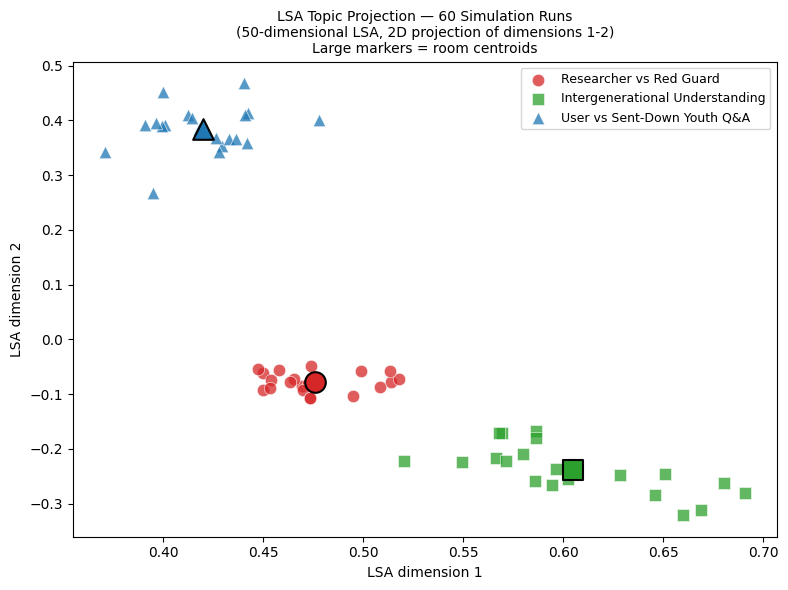

Saved -> eval_results/lsa_projection_claude.png

Top terms for LSA dimensions 1 and 2:
  Dimension 1: did, people, like, just, said, way, years, know, mother, didn
  Dimension 2: cold, shanghai, just, water, sisters, way, letter, like, letters, mother

Saved -> eval_results/lsa_consistency_claude.csv
                           room  n_runs   mean    std  n_pairs               method
        Researcher vs Red Guard      20 0.3142 0.0424      190 LSA TruncatedSVD 50d
Intergenerational Understanding      20 0.4613 0.0981      190 LSA TruncatedSVD 50d
    User vs Sent-Down Youth Q&A      20 0.2928 0.0518      190 LSA TruncatedSVD 50d


In [ ]:
#  LSA Topic Consistency

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize


ROOMS = [
    ("Researcher vs Red Guard",         Path("./runs/researcher_vs_redguard_claude")),
    ("Intergenerational Understanding", Path("./runs/intergenerational_claude")),
    ("User vs Sent-Down Youth Q&A",     Path("./runs/sentdown_qa_claude")),
]

OUT_DIR = Path("./eval_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE_AGENTS = {"User", "Moderator"}


N_COMPONENTS = 50


def load_runs(runs_dir: Path) -> list[list[dict]]:
    files = sorted(runs_dir.glob("run_*.json"))
    if not files:
        raise FileNotFoundError(f"No run_*.json files in {runs_dir}")
    runs = []
    for f in files:
        data = json.loads(f.read_text(encoding="utf-8"))
        if isinstance(data, dict):
            data = data.get("turns", data.get("messages", []))
        runs.append(data)
    return runs


def run_to_document(run: list[dict], exclude: set[str]) -> str:
    """Concatenate all non-excluded agent turns into one string."""
    return " ".join(
        turn["text"] for turn in run
        if turn["agent"] not in exclude
    )

corpus     = []
meta       = []

for room_name, runs_dir in ROOMS:
    runs = load_runs(runs_dir)
    for run_idx, run in enumerate(runs):
        doc = run_to_document(run, EXCLUDE_AGENTS)
        corpus.append(doc)
        meta.append({"room": room_name, "run_id": run_idx + 1})

print(f"Corpus: {len(corpus)} documents")
print(f"  {sum(len(d.split()) for d in corpus):,} total words")


print(f"\nFitting TF-IDF + LSA ({N_COMPONENTS} components) ...")

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    stop_words="english",
    ngram_range=(1, 2),
)
tfidf_matrix = vectorizer.fit_transform(corpus)
print(f"TF-IDF matrix: {tfidf_matrix.shape}")

lsa = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
lsa_matrix = lsa.fit_transform(tfidf_matrix)
lsa_matrix = normalize(lsa_matrix)

explained = lsa.explained_variance_ratio_.sum()
print(f"LSA matrix: {lsa_matrix.shape}")
print(f"Variance explained by {N_COMPONENTS} components: {explained:.1%}")


print(f"\n{'='*62}")
print("  LSA Topic Consistency per Room")
print(f"{'='*62}")
print(f"  {'Room':<38} {'Mean':>8} {'Std':>8} {'N Pairs':>9}")
print("  " + "-" * 62)

df_meta = pd.DataFrame(meta)
results = []

for room_name, _ in ROOMS:
    idx    = df_meta[df_meta["room"] == room_name].index.tolist()
    vecs   = lsa_matrix[idx]
    sim    = cosine_similarity(vecs)
    tri    = sim[np.triu_indices(len(sim), k=1)]
    m      = float(np.mean(tri))
    s      = float(np.std(tri))

    print(f"  {room_name:<38} {m:>8.4f} {s:>8.4f} {len(tri):>9}")
    results.append({
        "room":    room_name,
        "n_runs":  len(idx),
        "mean":    round(m, 4),
        "std":     round(s, 4),
        "n_pairs": len(tri),
        "method":  f"LSA TruncatedSVD {N_COMPONENTS}d",
    })

print(f"{'='*62}")
print("""
How to read:
  Mean — average cosine similarity between run LSA vectors
         in the same room (higher = more consistent topic structure)
  Std  — stability of that consistency across pairs
  Complements Cross-Run Semantic Similarity (turn-level) by
  measuring topic consistency at the whole-run level.
""")


room_colors = {
    "Researcher vs Red Guard":         "#d62728",
    "Intergenerational Understanding": "#2ca02c",
    "User vs Sent-Down Youth Q&A":     "#1f77b4",
}
room_markers = {
    "Researcher vs Red Guard":         "o",
    "Intergenerational Understanding": "s",
    "User vs Sent-Down Youth Q&A":     "^",
}

fig, ax = plt.subplots(figsize=(8, 6))

for room_name, _ in ROOMS:
    idx    = df_meta[df_meta["room"] == room_name].index.tolist()
    x      = lsa_matrix[idx, 0]
    y      = lsa_matrix[idx, 1]
    color  = room_colors[room_name]
    marker = room_markers[room_name]

    ax.scatter(x, y, c=color, marker=marker, s=80, alpha=0.75,
               label=room_name, edgecolors="white", linewidths=0.5)


    cx, cy = float(np.mean(x)), float(np.mean(y))
    ax.scatter(cx, cy, c=color, marker=marker, s=220,
               edgecolors="black", linewidths=1.5, zorder=5)

ax.set_xlabel("LSA dimension 1", fontsize=10)
ax.set_ylabel("LSA dimension 2", fontsize=10)
ax.set_title(
    "LSA Topic Projection — 60 Simulation Runs\n"
    f"({N_COMPONENTS}-dimensional LSA, 2D projection of dimensions 1-2)\n"
    "Large markers = room centroids",
    fontsize=10,
)
ax.legend(fontsize=9, loc="best")
plt.tight_layout()

plot_path = OUT_DIR / "lsa_projection_claude.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved -> {plot_path}")


print("\nTop terms for LSA dimensions 1 and 2:")
terms = vectorizer.get_feature_names_out()

for dim in [0, 1]:
    top_idx  = np.argsort(lsa.components_[dim])[::-1][:10]
    top_terms = [terms[i] for i in top_idx]
    print(f"  Dimension {dim + 1}: {', '.join(top_terms)}")


df_results = pd.DataFrame(results)
out_csv    = OUT_DIR / "lsa_consistency_claude.csv"
df_results.to_csv(out_csv, index=False)
print(f"\nSaved -> {out_csv}")
print(df_results.to_string(index=False))

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("simulations_claude", "zip", "./runs")
files.download("simulations_claude.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>